# SET UP

In [1]:
# --- ติดตั้ง Engine ของ Tesseract ---
!sudo apt install tesseract-ocr
!sudo apt install libtesseract-dev

# --- ติดตั้งไลบรารีที่จำเป็น (หากยังไม่ได้รัน) ---
!pip install pdf2image
!pip install poppler-utils
!pip install numpy
# ใช้ apt-get เพื่อติดตั้ง poppler-utils สำหรับระบบ (Debian/Ubuntu)
!sudo apt-get install -y poppler-utils

# --- ติดตั้ง Python Libraries ---
!pip install pytesseract
!pip install easyocr
!pip install transformers torch sentencepiece
!pip install pdf2image
!pip install poppler-utils # Dependency ของ pdf2image

!pip install openpyxl
!pip install jiwer

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
!pip install opencv-python-headless numpy matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libarchive-dev libleptonica-dev
The following NEW packages will be installed:
  libarchive-dev libleptonica-dev libtesseract-dev
0 upgraded, 3 newly installed, 0 to remove and 35 not upgraded.
Need to get 3,743 kB of archives.
After this operation, 16.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libarchive-dev amd64 3.6.0-1ubuntu1.4 [581 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libleptonica-dev amd64 1.82.0-3build1 [1,562 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libtesseract-dev amd64 4.1.1-2.1build1 [1,600 kB

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Convert  to image

In [ ]:
import os
from pdf2image import convert_from_path
from tqdm import tqdm # เพิ่ม tqdm เพื่อให้เห็น progress bar สวยๆ

# --- 1. ตั้งค่า Path ของโฟลเดอร์ ---
# !!! ให้แก้เป็น path ใน Google Drive ของคุณ !!!
PDF_FOLDER = '/content/drive/MyDrive/lastest-ktep/kmitl_dataset/dataset'
IMAGE_FOLDER = '/content/drive/MyDrive/lastest-ktep/conv-to-img'

# --- 2. สร้างโฟลเดอร์สำหรับเก็บภาพ (หากยังไม่มี) ---
os.makedirs(IMAGE_FOLDER, exist_ok=True)
print(f"ไฟล์รูปภาพจะถูกบันทึกไว้ที่: {IMAGE_FOLDER}")

# --- 3. ดึงรายชื่อไฟล์ PDF ทั้งหมด ---
try:
    # กรองเอาเฉพาะไฟล์ที่ลงท้ายด้วย .pdf หรือ .PDF
    #    files_to_process = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.pdf', '.png', '.jpg', '.jpeg'))]
    pdf_files = [f for f in os.listdir(PDF_FOLDER) if f.lower().endswith('.pdf')]
    if not pdf_files:
        print(f"ไม่พบไฟล์ PDF ในโฟลเดอร์: {PDF_FOLDER}")
    else:
        print(f"พบไฟล์ PDF ทั้งหมด {len(pdf_files)} ไฟล์ กำลังเริ่มทำการแปลง...")

        # --- 4. วนลูปเพื่อแปลงไฟล์ทั้งหมด ---
        for pdf_file in tqdm(pdf_files, desc="Converting PDFs to Images"):
            pdf_path = os.path.join(PDF_FOLDER, pdf_file)

            # ตั้งชื่อไฟล์ output ให้เหมือนไฟล์ input แต่เปลี่ยนนามสกุลเป็น .png
            output_filename = f"{os.path.splitext(pdf_file)[0]}.png"
            image_path = os.path.join(IMAGE_FOLDER, output_filename)

            # ตรวจสอบว่าไฟล์ภาพนี้เคยถูกสร้างไว้แล้วหรือยัง เพื่อจะได้ไม่ต้องทำซ้ำ
            if os.path.exists(image_path):
                # print(f"ข้ามไฟล์ {pdf_file} เนื่องจากมีไฟล์ภาพอยู่แล้ว")
                continue

            try:
                # แปลงไฟล์ PDF เป็นภาพ (เราเอาเฉพาะหน้าแรก)
                images = convert_from_path(pdf_path, dpi=300)
                if images:
                    images[0].save(image_path, 'PNG')
            except Exception as e:
                print(f"เกิดข้อผิดพลาดระหว่างแปลงไฟล์ {pdf_file}: {e}")

        print("\nการแปลงไฟล์ทั้งหมดเสร็จสมบูรณ์!")

except FileNotFoundError:
    print(f"ไม่พบโฟลเดอร์ต้นทาง: {PDF_FOLDER}")
    print("โปรดตรวจสอบว่า Path ถูกต้อง และคุณได้ Mount Google Drive แล้ว")

# Augment

Rotate

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

folder_path = "/content/drive/MyDrive/lastest-ktep/conv-to-img"

for filename in os.listdir(folder_path):
    img_path = os.path.join(folder_path, filename)
    img = cv2.imread(img_path)

    if img is None:
        print(f"Error: Could not load image at {img_path}. Please check the file path.")
    else:
        # สร้างโฟลเดอร์สำหรับบันทึกภาพ
        output_folder = "/content/drive/MyDrive/lastest-ktep/rotate_45"
        os.makedirs(output_folder, exist_ok=True)

        # ขนาดภาพต้นฉบับ
        (h, w) = img.shape[:2]

        # คำนวณขนาดพื้นหลังให้ใหญ่พอรองรับทุกการหมุน
        max_side = int(np.sqrt(w**2 + h**2))  # คำนวณเส้นทแยงมุม
        new_w, new_h = max_side, max_side  # กำหนดขนาดพื้นหลังใหม่

        # ค่ามุมหมุนที่ต้องการ
        rotation_angles = [-45, -30, -15, 15, 30, 45]

        plt.figure(figsize=(12, 6))

        for i, angle in enumerate(rotation_angles):

            # สร้างพื้นหลังสีขาวขนาดใหม่
            padded_img = np.full((new_h, new_w, 3), 255, dtype=np.uint8)  # พื้นหลังสีขาว

            # คำนวณตำแหน่งให้ภาพอยู่กลางพื้นหลัง
            center_x = (new_w - w) // 2
            center_y = (new_h - h) // 2

            # วางภาพต้นฉบับไว้ตรงกลางของพื้นหลัง
            padded_img[center_y:center_y + h, center_x:center_x + w] = img

            # หมุนภาพ
            center = (new_w // 2, new_h // 2)
            rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
            rotated_img = cv2.warpAffine(padded_img, rotation_matrix, (new_w, new_h),
                                        borderMode=cv2.BORDER_CONSTANT, borderValue=(255, 255, 255))

            # บันทึกภาพที่หมุนแล้ว
            save_path = os.path.join(output_folder, f'{filename}_rotated_{angle}.png')
            cv2.imwrite(save_path, rotated_img)

            # แสดงภาพ
            plt.subplot(2, 3, i + 1)
            plt.imshow(cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Rotation: {angle}°')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

        print("✅ เสร็จสิ้น! ภาพทั้งหมดถูกสร้างและบันทึกในโฟลเดอร์:", output_folder)


Correct 90

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

def correct_skew(image, debug_draw=False):
    """แก้ไขการเอียงของภาพโดยใช้ Hough Line Transform"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)

    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)
    angles = []

    if lines is not None:
        if debug_draw:
            debug_img = image.copy()
            for line in lines:
                x1, y1, x2, y2 = line[0]
                cv2.line(debug_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            plt.figure(figsize=(8, 6))
            plt.title("🔍 Hough Lines (Before Rotation)")
            plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()

        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
            angles.append(angle)

        median_angle = np.median(angles)
        print(f"🔄 Correcting skew by {median_angle:.2f}°")

        (h, w) = image.shape[:2]
        center = (w // 2, h // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, median_angle, 1.0)
        corrected_img = cv2.warpAffine(image, rotation_matrix, (w, h)) ############ borderMode-cv2.BORDER_CONSTANT,

        return corrected_img, median_angle
    else:
        print("⚠️ No lines found for skew correction.")
        return image, 0


def detect_text_region(image):
    """ ตรวจจับตำแหน่งของข้อความหรือขอบบนของเอกสาร """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # แปลงภาพเป็นขาวดำ
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)  # ลด noise ด้วย Gaussian Blur
    edges = cv2.Canny(blurred, 50, 150)  # ตรวจจับขอบภาพ

    # ค้นหา contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None  # ถ้าไม่มี contour ให้คืนค่า None

    # เรียงลำดับ contours ตามตำแหน่ง y (จากบนลงล่าง)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])
    return cv2.boundingRect(contours[0])  # คืนค่ากล่องที่อยู่ด้านบนสุด

#cv2.findContours() เป็นฟังก์ชันที่ใช้หาขอบเขตของวัตถุที่เชื่อมต่อกันในภาพ
#cv2.RETR_EXTERNAL จะคืนค่าเฉพาะ contour ที่อยู่รอบนอกสุด ของแต่ละวัตถุในภาพ
#cv2.CHAIN_APPROX_SIMPLE จะลดจำนวนจุดที่ไม่จำเป็นเพื่อลดขนาดของข้อมูล contour ที่ได้

#ตัวแปร contours จะเป็นลิสต์ของเส้นขอบของวัตถุที่พบในภาพ

def is_upside_down(image):
    """ ตรวจสอบว่าภาพกลับหัวหรือไม่โดยใช้การวิเคราะห์ตำแหน่งของข้อความ """
    text_region = detect_text_region(image)

    if text_region is None:
        print("⚠️ No text detected, assuming image is upside down.")
        return True  # ถ้าไม่มีข้อความ ให้ถือว่ากลับหัว

    x, y, w, h = text_region
    print(f"📝 Text detected at y={y}, height={h}")

    img_height = image.shape[0]

    if y > img_height // 2:
        print("❌ Text detected in lower half -> Image is upside down!")
        return True
    else:
        print("✅ Text detected in upper half -> Image is correct!")
        return False

def crop_white_background(image, tol=5):
    """ ตัดพื้นหลังสีขาวออกทั้งหมด โดยใช้ Contour Detection """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    mask = cv2.threshold(gray, 255 - tol, 255, cv2.THRESH_BINARY_INV)[1]  # สร้าง Mask ที่แสดงเฉพาะวัตถุ

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # หา Contours

    if not contours:
        return image  # ถ้าไม่มี contour ให้คืนภาพเดิม

    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))  # หาขอบเขตของวัตถุที่ใหญ่ที่สุด
    cropped = image[y:y+h, x:x+w]  # ครอบเฉพาะพื้นที่ที่มีวัตถุ

    return cropped

def process_images_in_folder(input_folder, output_folder):
    """ ประมวลผลภาพทั้งหมดในโฟลเดอร์โดยเรียงตามชื่อไฟล์ """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    file_list = sorted(os.listdir(input_folder))  # ✅ เรียงลำดับไฟล์ตามชื่อ

    for filename in file_list:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        if os.path.isdir(input_path):
            continue

        print(f"📌 Processing: {filename}")
        img = cv2.imread(input_path)

        if img is None:
            print(f"❌ Skipping {filename}: Cannot read image.")
            continue

        corrected_img, angle = correct_skew(img, debug_draw=True)  # ✅ แก้เอียงรูป

        if is_upside_down(corrected_img):  # ✅ ตรวจสอบว่ากลับหัวหรือไม่
            print(f"🔄 Rotating {filename} by 180°")
            corrected_img = cv2.rotate(corrected_img, cv2.ROTATE_180)

        cropped_img = crop_white_background(corrected_img)  # ✅ ตัดขอบขาวออก

        save_path = os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_corrected.png")
        cv2.imwrite(save_path, cropped_img)  # ✅ บันทึกภาพ
        print(f"✅ Saved corrected image to {save_path}")

        plt.figure(figsize=(6, 6))  # ✅ แสดงผลภาพ
        plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed: {filename}")
        plt.axis("off")
        plt.show()

# ระบุโฟลเดอร์ต้นทางและปลายทาง
input_folder = "/content/drive/MyDrive/lastest-ktep/rotate_45"
output_folder = "/content/drive/MyDrive/lastest-ktep/corrected"

# ✅ เรียกใช้งาน
process_images_in_folder(input_folder, output_folder)


Transparent  White BG

In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path

# ======= CONFIG =======
input_folder = "/content/drive/MyDrive/lastest-ktep/corrected"     # โฟลเดอร์ที่มีภาพต้นฉบับ
output_folder = "/content/drive/MyDrive/toeic_dataset/Transparented"       # โฟลเดอร์สำหรับบันทึกผลลัพธ์

# สร้าง output folder ถ้ายังไม่มี
os.makedirs(output_folder, exist_ok=True)

# รูปแบบไฟล์ที่รองรับ
valid_exts = ('.png', '.jpg', '.jpeg')

# วนลูปภาพทั้งหมดใน input folder
for filename in os.listdir(input_folder):
    if filename.lower().endswith(valid_exts):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, Path(filename).stem + ".png")

        # โหลดภาพ
        image = cv2.imread(input_path)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Threshold เพื่อหาส่วนที่ไม่ใช่พื้นหลังสีขาว
        _, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

        # หา contour ใหญ่สุด และครอป
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            print(f"❌ No content found in {filename}")
            continue

        x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
        cropped = image[y:y+h, x:x+w]
        mask_cropped = mask[y:y+h, x:x+w]

        # สร้าง alpha channel และรวมเป็น BGRA
        bgra = cv2.cvtColor(cropped, cv2.COLOR_BGR2BGRA)
        bgra[:, :, 3] = mask_cropped

        # บันทึกภาพผลลัพธ์
        cv2.imwrite(output_path, bgra)
        print(f"✅ Processed and saved: {output_path}")

Preprocess HSV Black-white

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# --- 1. ตั้งค่า Path ของโฟลเดอร์ ---
# !!! ให้แก้เป็น path ใน Google Drive ของคุณ !!!

# โฟลเดอร์ที่เก็บภาพสีต้นฉบับ (ที่แปลงจาก PDF)
INPUT_IMAGE_FOLDER = "/content/drive/MyDrive/toeic_dataset/Transparented"

# โฟลเดอร์ที่จะใช้เก็บภาพขาวดำที่ผ่าน Preprocessing แล้ว
OUTPUT_PROCESSED_FOLDER = '/content/drive/MyDrive/lastest-ktep/HSV-B-W'

# --- 2. สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์ (หากยังไม่มี) ---
os.makedirs(OUTPUT_PROCESSED_FOLDER, exist_ok=True)
print(f"รูปภาพที่ประมวลผลแล้วจะถูกบันทึกที่: {OUTPUT_PROCESSED_FOLDER}")


# --- 3. ฟังก์ชัน Preprocessing ที่ดีที่สุดของเรา ---
def create_ocr_ready_image(image_path):
    """
    อ่านภาพสี, ใช้ HSV Mask เพื่อแยกตัวอักษร, และแปลงเป็นภาพขาวดำ
    """
    image = cv2.imread(image_path)
    if image is None:
        return None # กรณีอ่านไฟล์ภาพไม่ได้

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # กำหนดช่วงสีดำและน้ำเงิน
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([180, 255, 120])
    lower_blue = np.array([90, 50, 50])
    upper_blue = np.array([130, 255, 255])

    # สร้างและรวม Mask
    mask_black = cv2.inRange(hsv, lower_black, upper_black)
    mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)
    combined_mask = cv2.bitwise_or(mask_black, mask_blue)

    # สลับสี (Invert) เพื่อให้ตัวอักษรเป็นสีดำ พื้นหลังเป็นสีขาว
    final_binary_image = cv2.bitwise_not(combined_mask)

    return final_binary_image


# --- 4. เริ่มกระบวนการ xử lý ทั้งหมดในโฟลเดอร์ ---
try:
    # กรองเอารายชื่อไฟล์รูปภาพ
    image_files = [f for f in os.listdir(INPUT_IMAGE_FOLDER) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"พบรูปภาพทั้งหมด {len(image_files)} รูป, กำลังเริ่มประมวลผล...")

    # วนลูปเพื่อประมวลผลทีละไฟล์
    for filename in tqdm(image_files, desc="Processing Images"):
        input_path = os.path.join(INPUT_IMAGE_FOLDER, filename)
        output_path = os.path.join(OUTPUT_PROCESSED_FOLDER, filename)

        # ข้ามไฟล์ที่เคยทำไปแล้ว
        if os.path.exists(output_path):
            continue

        try:
            # ประมวลผลภาพ
            ocr_ready_image = create_ocr_ready_image(input_path)
            if ocr_ready_image is not None:
                # บันทึกผลลัพธ์
                cv2.imwrite(output_path, ocr_ready_image)
        except Exception as e:
            print(f"\nเกิดข้อผิดพลาดระหว่างประมวลผลไฟล์ {filename}: {e}")

    print("\nประมวลผลรูปภาพทั้งหมดเสร็จสมบูรณ์!")

except FileNotFoundError:
    print(f"\nERROR: ไม่พบโฟลเดอร์ {INPUT_IMAGE_FOLDER}. กรุณาตรวจสอบ Path อีกครั้ง")

Resizing

In [ ]:
import cv2
import os
from tqdm import tqdm
from pathlib import Path

# --- 1. กำหนดค่าและ Path ---
# ⬇️⬇️⬇️ กรุณาแก้ไข Path ให้ถูกต้อง ⬇️⬇️⬇️

# โฟลเดอร์ที่เก็บรูปภาพที่คุณต้องการปรับขนาด
INPUT_FOLDER = "/content/drive/MyDrive/lastest-ktep/HSV-B-W"

# โฟลเดอร์สำหรับเก็บรูปภาพที่ปรับขนาดแล้ว
OUTPUT_FOLDER = "/content/drive/MyDrive/lastest-ktep/HSV_resized"

# --- 2. กำหนดขนาดสุดท้ายที่ต้องการ ---
FINAL_WIDTH = 2480
FINAL_HEIGHT = 1759

# --- 3. สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์ (หากยังไม่มี) ---
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
print(f"รูปภาพที่ปรับขนาดแล้วจะถูกบันทึกที่: {OUTPUT_FOLDER}")


# --- 4. เริ่มกระบวนการปรับขนาดทั้งหมดในโฟลเดอร์ ---
def resize_images_in_folder(input_dir, output_dir, target_width, target_height):

    # ดึงรายชื่อไฟล์ภาพทั้งหมด
    try:
        image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not image_files:
            print(f"ไม่พบไฟล์รูปภาพในโฟลเดอร์: {input_dir}")
            return
    except FileNotFoundError:
        print(f"[ERROR] ไม่พบโฟลเดอร์ต้นทาง: {input_dir}")
        return

    print(f"พบรูปภาพทั้งหมด {len(image_files)} รูป, กำลังเริ่มปรับขนาด...")

    # วนลูปเพื่อประมวลผลทีละไฟล์
    for filename in tqdm(image_files, desc="Resizing Images"):
        input_path = os.path.join(input_dir, filename)

        # สร้างชื่อไฟล์ใหม่ในโฟลเดอร์ปลายทาง
        # ใช้ Path(filename).stem เพื่อเอาเฉพาะชื่อไฟล์ไม่รวมนามสกุล
        save_path = os.path.join(output_dir, Path(filename).stem + ".png") # บันทึกเป็น PNG เพื่อคุณภาพดีที่สุด

        # ข้ามไฟล์ที่เคยทำไปแล้ว
        if os.path.exists(save_path):
            continue

        try:
            # อ่านภาพ
            image = cv2.imread(input_path, cv2.IMREAD_UNCHANGED) # IMREAD_UNCHANGED เพื่อรักษา Alpha channel
            if image is None:
                print(f"Warning: ไม่สามารถอ่านไฟล์ {filename}, ข้ามไฟล์นี้")
                continue

            # ปรับขนาดภาพด้วยอัลกอริทึม INTER_LANCZOS4 ซึ่งให้คุณภาพดีที่สุด
            resized_image = cv2.resize(image, (target_width, target_height), interpolation=cv2.INTER_LANCZOS4)

            # บันทึกภาพที่ปรับขนาดแล้ว
            cv2.imwrite(save_path, resized_image)

        except Exception as e:
            print(f"\nเกิดข้อผิดพลาดระหว่างประมวลผลไฟล์ {filename}: {e}")

    print("\n--- ✅ ปรับขนาดรูปภาพทั้งหมดเสร็จสมบูรณ์! ---")


# --- เรียกใช้งานฟังก์ชัน ---
resize_images_in_folder(INPUT_FOLDER, OUTPUT_FOLDER, FINAL_WIDTH, FINAL_HEIGHT)

# พิกัด ROI ที่แน่นอน x= แนวนอน, y= แนวตั้ง, w=กว้าง, h=สูง
ROI_CONFIG = {
    'name': (225, 700, 800, 100), 'application_no': (1675, 700, 500, 100),
    'test_date': (2010, 800, 450, 100), 'overall_score': (1600, 930, 800, 180),
    'grammar': (420, 1225, 500, 120), 'reading': (1600, 1225, 500, 120),
    'speaking': (420, 1410, 500, 120), 'writing': (1600, 1410, 500, 120),
}

# Pytesseract ******** finish

# Pure Pytes Auto

In [4]:
import cv2
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image
import pytesseract
import jiwer # ถึงแม้จะมี conflict ในบางเวอร์ชัน แต่ยังต้อง import เพื่อใช้ฟังก์ชันพื้นฐาน

# --- 1. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'Tesseract'
APPROACH_NAME = 'Pure OCR' # <--- เปลี่ยนชื่อแนวทาง
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized" # <--- ใช้ภาพชุดเดียวกับ Boxing OCR ได้เลย
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

print(f"--- ⚙️ เริ่มการตั้งค่าสำหรับ: {MODEL_NAME} ({APPROACH_NAME}) ---")


# --- 2. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

# ⬇️⬇️⬇️ ใช้ Parser ตัวเต็มสำหรับ Pure OCR ⬇️⬇️⬇️
def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('L', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)

    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application\s*No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None

    total_block = re.search(r"KMITL-TEP Level(.*?)(Grammar|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*?)(This is part|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data
# ⬆️⬆️⬆️ สิ้นสุดส่วน Parser ⬆️⬆️⬆️


# --- 3. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    !pip install openpyxl jiwer -q
    import openpyxl
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()


# --- 4. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)

    # ⬇️⬇️⬇️ ส่วนที่แก้ไขสำหรับ Pure OCR ⬇️⬇️⬇️
    try:
        # ใช้ PSM 3 เพื่อให้ Tesseract วิเคราะห์ Layout ของทั้งหน้าโดยอัตโนมัติ
        config = r'--oem 3 --psm 3'
        full_text = pytesseract.image_to_string(image_path, config=config)

        # เรียกใช้ Parser ที่เราพัฒนาขึ้นเพื่อสกัดข้อมูลจากข้อความทั้งหมด
        extracted_data = final_robust_parser(full_text)

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 5. เริ่มกระบวนการประเมินผล (Evaluation) ---
# ส่วนนี้สามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except (ValueError, AttributeError): # ดักจับทั้ง 2 error ที่อาจเกิดขึ้น
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 6. บันทึกผลลัพธ์ ---
    # ส่วนนี้สามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- ⚙️ เริ่มการตั้งค่าสำหรับ: Tesseract (Pure OCR) ---
--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย Tesseract (Pure OCR) ---


Processing with Tesseract: 100%|██████████| 756/756 [22:28<00:00,  1.78s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
    Model Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Tesseract Pure OCR            Name         79.10    20.90     1.87         79.15
Tesseract Pure OCR Application No.         99.47     0.53     0.26         99.54
Tesseract Pure OCR       Test Date         99.87     0.13     0.13         99.93
Tesseract Pure OCR   Grammar_Level         45.63    54.37    50.73         59.69
Tesseract Pure OCR   Grammar_Score         52.91    47.09    46.76         69.20
Tesseract Pure OCR   Reading_Level         66.80    33.20    25.79         73.56
Tesseract Pure OCR   Reading_Score         81.61    18.39    18.26         89.88
Tesseract Pure OCR  Speaking_Level         73.54    26.46    19.18         78.20
Tesseract Pure OCR  Speaking_Score         88.10    11.90    11.90         93.67
Tesseract Pure OCR   Writing_Level         88.10    11.90    11.38         93.15
Tesseract Pure OCR   Writing_Score         88.76  

#Pytes Boxing Auto

สภาพแวดล้อมของคุณ: ในเซสชันของ Colab ที่คุณกำลังรันอยู่ตอนนี้ มีไลบรารี jiwer เวอร์ชันเก่า ติดตั้งอยู่ ซึ่งยังไม่มีฟังก์ชันที่ชื่อว่า compute_measures

In [3]:
import cv2
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image
import pytesseract

# --- 1. ติดตั้งไลบรารี jiwer ---
# (ถึงแม้จะเกิด conflict เรายังคงต้อง import มัน)
!pip install jiwer -q
import jiwer

# --- 2. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'Tesseract'
APPROACH_NAME = 'Boxing OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# พิกัด ROI ที่แน่นอน
ROI_CONFIG = {
    'name': (225, 700, 800, 100), 'application_no': (1675, 700, 500, 100),
    'test_date': (2010, 800, 450, 100), 'overall_score': (1600, 930, 800, 180),
    'grammar': (420, 1225, 500, 120), 'reading': (1600, 1225, 500, 120),
    'speaking': (420, 1410, 500, 120), 'writing': (1600, 1410, 500, 120),
}

# --- 3. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def parse_level_and_score(text):
    if not text: return None, None
    cleaned_text = text.upper().replace('I','1').replace('L','1').replace(' ','')
    match = re.search(r"([A-Z1-9]+)\((\d+)\)", cleaned_text)
    if match:
        level, score = match.group(1), match.group(2)
        if len(level) > 2 and level.startswith('B'): level = 'B1'
        return level, score
    return None, None

# --- 4. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    !pip install openpyxl -q
    import openpyxl
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()

# --- 5. เริ่มกระบวนการสกัดข้อมูล ---
results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)
    try:
        image_pil = Image.open(image_path)
        extracted_data = {}
        for field, (x, y, w, h) in ROI_CONFIG.items():
            x1, y1, x2, y2 = x, y, x + w, y + h
            cropped_box = image_pil.crop((x1, y1, x2, y2))
            config = r'--oem 3 --psm 7'
            text = pytesseract.image_to_string(cropped_box, config=config).strip()
            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text
    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })
ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 6. เริ่มกระบวนการประเมินผล (Evaluation) ---
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    # ⬇️⬇️⬇️ ส่วนที่แก้ไข: เปลี่ยนมาใช้ jiwer.wer และ jiwer.cer โดยตรง ⬇️⬇️⬇️
    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            # คำนวณ WER และ CER แยกกัน
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100

            # F1-score ยังคงคำนวณแบบเดิมได้
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except ValueError:
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 7. บันทึกผลลัพธ์ ---
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย Tesseract (Boxing OCR) ---


Processing with Tesseract: 100%|██████████| 756/756 [18:59<00:00,  1.51s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
    Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Tesseract Boxing OCR            Name         99.07     0.93     0.19         99.07
Tesseract Boxing OCR Application No.         99.60     0.40     0.31         99.60
Tesseract Boxing OCR       Test Date         99.87     0.13     0.13         99.87
Tesseract Boxing OCR   Grammar_Level         99.87     0.13     0.13         99.93
Tesseract Boxing OCR   Grammar_Score         99.87     0.13     0.13         99.93
Tesseract Boxing OCR   Reading_Level         99.87     0.13     0.13         99.93
Tesseract Boxing OCR   Reading_Score         99.87     0.13     0.13         99.93
Tesseract Boxing OCR  Speaking_Level         99.87     0.13     0.13         99.93
Tesseract Boxing OCR  Speaking_Score         99.87     0.13     0.13         99.93
Tesseract Boxing OCR   Writing_Level         99.87     0.13     0.13         99.93
Tesseract Boxing OCR   Writi

# Easy OCR **********Not yet

#Pure easy Auto

In [5]:
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
print("--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---")
!pip install easyocr openpyxl jiwer -q
import easyocr
import jiwer

# --- 2. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'EasyOCR' # <--- เปลี่ยนชื่อโมเดล
APPROACH_NAME = 'Pure OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

print(f"--- ⚙️ เริ่มการตั้งค่าสำหรับ: {MODEL_NAME} ({APPROACH_NAME}) ---")

# --- 3. ฟังก์ชันช่วยเหลือ (ใช้ชุดเดียวกับ Tesseract) ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('L', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)

    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application\s*No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None

    total_block = re.search(r"KMITL-TEP Level(.*?)(Grammar|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*?)(This is part|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data

# --- 4. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()

# --- 5. เริ่มกระบวนการสกัดข้อมูล ---
# ⬇️⬇️⬇️ ส่วนที่แก้ไขสำหรับ EasyOCR ⬇️⬇️⬇️
# โหลดโมเดล EasyOCR นอกลูป เพื่อความรวดเร็ว
print("--- ⚙️ กำลังโหลดโมเดล EasyOCR (อาจใช้เวลาสักครู่)... ---")
reader = easyocr.Reader(['en'], gpu=True) # ตั้งเป็น True เพื่อใช้ GPU หากมี
print("--- ✅ โหลดโมเดล EasyOCR สำเร็จ ---")

results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        # สั่งให้ EasyOCR อ่านภาพทั้งแผ่น และรวมผลลัพธ์เป็นก้อนเดียว
        # detail=0 คือการเอาเฉพาะข้อความ, paragraph=True ช่วยรวมประโยคที่ใกล้กัน
        ocr_results = reader.readtext(image_path, detail=0, paragraph=True)
        full_text = "\n".join(ocr_results)

        # เรียกใช้ Parser ตัวเดิมเพื่อสกัดข้อมูล
        extracted_data = final_robust_parser(full_text)

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    # ส่วนของการเก็บข้อมูลเหมือนเดิม
    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 6. เริ่มกระบวนการประเมินผล (Evaluation) ---
# ส่วนนี้ทั้งหมดสามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except (ValueError, AttributeError):
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 7. บันทึกผลลัพธ์ (ใช้ร่วมกันได้) ---
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---
--- ⚙️ เริ่มการตั้งค่าสำหรับ: EasyOCR (Pure OCR) ---
--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- ⚙️ กำลังโหลดโมเดล EasyOCR (อาจใช้เวลาสักครู่)... ---
--- ✅ โหลดโมเดล EasyOCR สำเร็จ ---
--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย EasyOCR (Pure OCR) ---


Processing with EasyOCR: 100%|██████████| 756/756 [21:30<00:00,  1.71s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
  Model Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
EasyOCR Pure OCR            Name         98.54     1.46     0.24         98.61
EasyOCR Pure OCR Application No.         99.74     0.26     0.18         99.80
EasyOCR Pure OCR       Test Date         98.94     1.06     1.06         99.47
EasyOCR Pure OCR   Grammar_Level         73.15    26.85    26.59         84.23
EasyOCR Pure OCR   Grammar_Score         73.68    26.32    26.86         84.84
EasyOCR Pure OCR   Reading_Level         66.14    33.86    33.80         79.55
EasyOCR Pure OCR   Reading_Score         66.27    33.73    33.73         79.71
EasyOCR Pure OCR  Speaking_Level         85.58    14.42    14.42         92.23
EasyOCR Pure OCR  Speaking_Score         85.58    14.42    14.42         92.23
EasyOCR Pure OCR   Writing_Level         69.71    30.29    30.29         82.15
EasyOCR Pure OCR   Writing_Score         69.71    30.29    30.29        

# Easy Boxing Auto

In [3]:
import cv2
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
print("--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---")
!pip install easyocr openpyxl jiwer -q
import easyocr
import jiwer

# --- 2. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'EasyOCR'
APPROACH_NAME = 'Boxing OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# พิกัด ROI ที่แน่นอน
ROI_CONFIG = {
    'name': (225, 700, 800, 100), 'application_no': (1675, 700, 500, 100),
    'test_date': (2010, 800, 450, 100), 'overall_score': (1600, 930, 800, 180),
    'grammar': (420, 1225, 500, 120), 'reading': (1600, 1225, 500, 120),
    'speaking': (420, 1410, 500, 120), 'writing': (1600, 1410, 500, 120),
}

print(f"--- ⚙️ เริ่มการตั้งค่าสำหรับ: {MODEL_NAME} ({APPROACH_NAME}) ---")

# --- 3. ฟังก์ชันช่วยเหลือ ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def parse_level_and_score(text):
    if not text: return None, None
    cleaned_text = text.upper().replace('I','1').replace('L','1').replace(' ','')
    match = re.search(r"([A-Z1-9]+)\s*\(?(\d+)\)?", cleaned_text) # ทำให้วงเล็บเป็น optional
    if match:
        level, score = match.group(1), match.group(2)
        if len(level) > 2 and level.startswith('B'): level = 'B1' # แก้ไขเคส B13 -> B1
        return level, score
    return None, None

# --- 4. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()

# --- 5. เริ่มกระบวนการสกัดข้อมูล ---
# โหลดโมเดล EasyOCR นอกลูป เพื่อความรวดเร็ว
print("--- ⚙️ กำลังโหลดโมเดล EasyOCR (อาจใช้เวลาสักครู่)... ---")
reader = easyocr.Reader(['en'], gpu=True)
print("--- ✅ โหลดโมเดล EasyOCR สำเร็จ ---")

results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)

    # ⬇️⬇️⬇️ ส่วนที่แก้ไขสำหรับ EasyOCR (Boxing) ⬇️⬇️⬇️
    try:
        # อ่านภาพด้วย OpenCV เพียงครั้งเดียว
        image = cv2.imread(image_path)
        if image is None:
            print(f"ไม่สามารถอ่านไฟล์ {filename}, ข้าม...")
            continue

        extracted_data = {}
        # วนลูปตามพิกัด ROI เพื่อตัดและ OCR ทีละส่วน
        for field, (x, y, w, h) in ROI_CONFIG.items():
            # ตัดภาพตามพิกัด
            cropped_roi = image[y:y+h, x:x+w]

            # สั่งให้ EasyOCR อ่านภาพชิ้นเล็กๆ นั้น
            # detail=0 คือเอาเฉพาะข้อความ, อาจได้ผลลัพธ์เป็น list ของ string
            ocr_results_in_box = reader.readtext(cropped_roi, detail=0)
            text = " ".join(ocr_results_in_box).strip() # นำข้อความที่อาจแยกส่วนกันมาต่อกัน

            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 6. เริ่มกระบวนการประเมินผล (Evaluation) ---
# ส่วนนี้ทั้งหมดสามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except (ValueError, AttributeError):
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 7. บันทึกผลลัพธ์ (ใช้ร่วมกันได้) ---
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---
--- ⚙️ เริ่มการตั้งค่าสำหรับ: EasyOCR (Boxing OCR) ---
--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---


พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- ⚙️ กำลังโหลดโมเดล EasyOCR (อาจใช้เวลาสักครู่)... ---
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete--- ✅ โหลดโมเดล EasyOCR สำเร็จ ---
--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย EasyOCR (Boxing OCR) ---


Processing with EasyOCR: 100%|██████████| 756/756 [14:42<00:00,  1.17s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
  Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
EasyOCR Boxing OCR            Name         98.41     1.59     0.24         98.41
EasyOCR Boxing OCR Application No.         99.74     0.26     0.40         99.74
EasyOCR Boxing OCR       Test Date         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Grammar_Level         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Grammar_Score         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Reading_Level         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Reading_Score         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR  Speaking_Level         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR  Speaking_Score         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Writing_Level         99.87     0.13     0.13         99.93
EasyOCR Boxing OCR   Writing_Score         99.87  

# TRocr **Not yet

# TRocr Pure  auto

นี่คือโค้ดสำหรับแนวทาง "Pure OCR" โดยใช้โมเดล TrOCR ซึ่งเป็นโมเดลที่ทันสมัยและมีประสิทธิภาพสูง

หลักการทำงานคือ:

โหลดโมเดล TrOCR ที่ซับซ้อนขึ้นมาเตรียมไว้
สั่งให้ TrOCR อ่านภาพทั้งแผ่นในครั้งเดียว เพื่อให้ได้ข้อความทั้งหมดออกมา
ใช้ Regex Parser ตัวเก่งของเรา (final_robust_parser) ในการวิเคราะห์และสกัดข้อมูลจากก้อนข้อความนั้น
ประเมินผลและบันทึกรายงานตามปกติ


In [6]:
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
print("--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---")
# ติดตั้ง transformers, torch และไลบรารีอื่นๆ ที่จำเป็น
!pip install transformers torch sentencepiece openpyxl jiwer -q
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import jiwer

# --- 2. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'TrOCR'
APPROACH_NAME = 'Pure OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

print(f"--- ⚙️ เริ่มการตั้งค่าสำหรับ: {MODEL_NAME} ({APPROACH_NAME}) ---")


# --- 3. ฟังก์ชันช่วยเหลือ (ใช้ Parser ตัวเต็ม) ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def final_robust_parser(full_text):
    data = {}
    def clean_level(level_text):
        if not level_text: return None
        cleaned = level_text.upper().replace('I', '1').replace('L', '1')
        if 'B11' in cleaned: return 'B1'
        return cleaned
    def parse_score(text):
        if not text: return None, None
        match = re.search(r"([A-Z1-9]+)\s*\(\s*(\d+)\)", text)
        return (clean_level(match.group(1)), match.group(2)) if match else (None, None)

    name_match = re.search(r"Name\s*:?\s*(.*?)\s*(?:Application No|Date of test)", full_text, re.DOTALL | re.IGNORECASE)
    data['name'] = re.sub(r'\s+', ' ', name_match.group(1).strip()) if name_match else None
    app_no_match = re.search(r"Application\s*No\.?\s*:*\s*([A-Z0-9\-]+)", full_text, re.IGNORECASE)
    data['application_no'] = app_no_match.group(1).strip() if app_no_match else None
    date_match = re.search(r"Administration\s*:?\s*([A-Za-z]+\s+\d{1,2},\s+\d{4})", full_text, re.IGNORECASE)
    data['test_date'] = date_match.group(1).strip() if date_match else None

    total_block = re.search(r"KMITL-TEP Level(.*?)(Grammar|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['total_level'], data['total_score'] = parse_score(total_block.group(1) if total_block else "")
    grammar_block = re.search(r"Grammar(.*?)Reading", full_text, re.DOTALL | re.IGNORECASE)
    data['grammar_level'], data['grammar_score'] = parse_score(grammar_block.group(1) if grammar_block else "")
    reading_block = re.search(r"Reading(.*?)Speaking", full_text, re.DOTALL | re.IGNORECASE)
    data['reading_level'], data['reading_score'] = parse_score(reading_block.group(1) if reading_block else "")
    speaking_block = re.search(r"Speaking(.*?)Writing", full_text, re.DOTALL | re.IGNORECASE)
    data['speaking_level'], data['speaking_score'] = parse_score(speaking_block.group(1) if speaking_block else "")
    writing_block = re.search(r"Writing(.*?)(This is part|$)", full_text, re.DOTALL | re.IGNORECASE)
    data['writing_level'], data['writing_score'] = parse_score(writing_block.group(1) if writing_block else "")
    return data


# --- 4. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()

# --- 5. เริ่มกระบวนการสกัดข้อมูล ---
# ⬇️⬇️⬇️ ส่วนที่แก้ไขสำหรับ TrOCR (Pure OCR) ⬇️⬇️⬇️
# โหลดโมเดลและ Processor นอกลูป เพื่อความรวดเร็ว
MODEL_PATH = "microsoft/trocr-base-printed"
print(f"--- ⚙️ กำลังโหลดโมเดล TrOCR: {MODEL_PATH} (อาจใช้เวลาสักครู่)... ---")
processor = TrOCRProcessor.from_pretrained(MODEL_PATH)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH)
# ย้ายโมเดลไป GPU หากมี
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"--- ✅ โหลดโมเดล TrOCR สำเร็จ (ทำงานบน: {device.upper()}) ---")

results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        # อ่านภาพด้วย PIL ซึ่งเป็นที่ต้องการของ transformers
        image = Image.open(image_path).convert("RGB")

        # ประมวลผลภาพทั้งแผ่น และส่งเข้าโมเดล
        pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
        generated_ids = model.generate(pixel_values)

        # ถอดรหัสผลลัพธ์กลับมาเป็นข้อความก้อนเดียว
        full_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # เรียกใช้ Parser ตัวเก่งของเราเพื่อสกัดข้อมูล
        extracted_data = final_robust_parser(full_text)

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 6. เริ่มกระบวนการประเมินผล (Evaluation) ---
# ส่วนนี้ทั้งหมดสามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except (ValueError, AttributeError):
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 7. บันทึกผลลัพธ์ (ใช้ร่วมกันได้) ---
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---
--- ⚙️ เริ่มการตั้งค่าสำหรับ: TrOCR (Pure OCR) ---
--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- ⚙️ กำลังโหลดโมเดล TrOCR: microsoft/trocr-base-printed (อาจใช้เวลาสักครู่)... ---


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- ✅ โหลดโมเดล TrOCR สำเร็จ (ทำงานบน: CUDA) ---
--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย TrOCR (Pure OCR) ---


Processing with TrOCR: 100%|██████████| 756/756 [03:17<00:00,  3.83it/s]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
Model Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
TrOCR Pure OCR            Name           0.0    100.0    100.0             0
TrOCR Pure OCR Application No.           0.0    100.0    100.0             0
TrOCR Pure OCR       Test Date           0.0    100.0    100.0             0
TrOCR Pure OCR   Grammar_Level           0.0    100.0    100.0             0
TrOCR Pure OCR   Grammar_Score           0.0    100.0    100.0             0
TrOCR Pure OCR   Reading_Level           0.0    100.0    100.0             0
TrOCR Pure OCR   Reading_Score           0.0    100.0    100.0             0
TrOCR Pure OCR  Speaking_Level           0.0    100.0    100.0             0
TrOCR Pure OCR  Speaking_Score           0.0    100.0    100.0             0
TrOCR Pure OCR   Writing_Level           0.0    100.0    100.0             0
TrOCR Pure OCR   Writing_Score           0.0    100.0    100.0             0
TrOCR Pure OCR   

# TRocr Boxing auto

In [4]:
import pandas as pd
import os
import re
import numpy as np
from tqdm import tqdm
from PIL import Image

# --- 1. ติดตั้งไลบรารีที่จำเป็น ---
print("--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---")
# ติดตั้ง transformers, torch และไลบรารีอื่นๆ ที่จำเป็น
!pip install transformers torch sentencepiece openpyxl jiwer -q
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import jiwer

# --- 2. กำหนดค่าและ Path ที่สำคัญ ---
MODEL_NAME = 'TrOCR'
APPROACH_NAME = 'Boxing OCR'
MASTER_OUTPUT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
INDIVIDUAL_REPORT_PATH = f"/content/drive/MyDrive/lastest-ktep/excel/{MODEL_NAME.lower()}_{APPROACH_NAME.replace(' ', '_').lower()}_report.xlsx"
IMAGE_DIR = "/content/drive/MyDrive/lastest-ktep/HSV_resized"
GROUND_TRUTH_PATH = "/content/drive/MyDrive/lastest-ktep/excel/คะแนน TEP (Pilot Study)_Total_IT.xlsx"

# พิกัด ROI ที่แน่นอน
ROI_CONFIG = {
    'name': (225, 700, 800, 100), 'application_no': (1675, 700, 500, 100),
    'test_date': (2010, 800, 450, 100), 'overall_score': (1600, 930, 800, 180),
    'grammar': (420, 1225, 500, 120), 'reading': (1600, 1225, 500, 120),
    'speaking': (420, 1410, 500, 120), 'writing': (1600, 1410, 500, 120),
}

print(f"--- ⚙️ เริ่มการตั้งค่าสำหรับ: {MODEL_NAME} ({APPROACH_NAME}) ---")

# --- 3. ฟังก์ชันช่วยเหลือ (ใช้ชุดเดิม) ---
def get_id_from_filename(filename):
    match = re.search(r'KMITL-TEP PILOT-(\d+)', filename, re.IGNORECASE)
    if match: return int(match.group(1))
    match = re.search(r'^(\d+)', filename)
    if match: return int(match.group(1))
    return None

def normalize_text(text):
    if text is None: return ""
    text_str = str(text).strip().lower().replace(' ', '')
    if text_str.endswith('.0'): text_str = text_str[:-2]
    return text_str

def parse_level_and_score(text):
    if not text: return None, None
    cleaned_text = text.upper().replace('I','1').replace('L','1').replace(' ','')
    match = re.search(r"([A-Z1-9]+)\s*\(?(\d+)\)?", cleaned_text)
    if match:
        level, score = match.group(1), match.group(2)
        if len(level) > 2 and level.startswith('B'): level = 'B1'
        return level, score
    return None, None

# --- 4. โหลดและตรวจสอบข้อมูลก่อนเริ่ม ---
print("--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---")
try:
    gt_df = pd.read_excel(GROUND_TRUTH_PATH, dtype={'Application No.': str})
    gt_df['No.'] = gt_df['No.'].astype(int)
    image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))], key=lambda f: get_id_from_filename(f) or 0)
    print(f"พบ ID ใน Ground Truth ทั้งหมด: {len(gt_df['No.'].unique())} ID | พบไฟล์รูปภาพ: {len(image_files)} ไฟล์")
    print("--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---\n")
except Exception as e:
    print(f"!!! Error during setup: {e}")
    exit()

# --- 5. เริ่มกระบวนการสกัดข้อมูล ---
# ⬇️⬇️⬇️ ส่วนที่แก้ไขสำหรับ TrOCR ⬇️⬇️⬇️
# โหลดโมเดลและ Processor นอกลูป เพื่อความรวดเร็ว
# เราใช้โมเดลสำหรับ "Printed" text ซึ่งเหมาะกับงานนี้
MODEL_PATH = "microsoft/trocr-base-printed"
print(f"--- ⚙️ กำลังโหลดโมเดล TrOCR: {MODEL_PATH} (อาจใช้เวลาสักครู่)... ---")
processor = TrOCRProcessor.from_pretrained(MODEL_PATH)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_PATH)
# ย้ายโมเดลไป GPU หากมี
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"--- ✅ โหลดโมเดล TrOCR สำเร็จ (ทำงานบน: {device.upper()}) ---")

results_list = []
print(f"--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ {len(image_files)} ไฟล์ ด้วย {MODEL_NAME} ({APPROACH_NAME}) ---")
for filename in tqdm(image_files, desc=f"Processing with {MODEL_NAME}"):
    image_id = get_id_from_filename(filename)
    if image_id is None: continue
    gt_row_df = gt_df[gt_df['No.'] == image_id]
    if gt_row_df.empty: continue
    gt_row = gt_row_df.iloc[0]
    image_path = os.path.join(IMAGE_DIR, filename)

    try:
        # อ่านภาพด้วย PIL ซึ่งเป็นที่ต้องการของ transformers
        image = Image.open(image_path).convert("RGB")

        extracted_data = {}
        # วนลูปตามพิกัด ROI เพื่อตัดและ OCR ทีละส่วน
        for field, (x, y, w, h) in ROI_CONFIG.items():
            # ตัดภาพ (Crop) ตามพิกัด
            x1, y1, x2, y2 = x, y, x + w, y + h
            cropped_box = image.crop((x1, y1, x2, y2))

            # ประมวลผลภาพชิ้นเล็กๆ และส่งเข้าโมเดล
            pixel_values = processor(images=cropped_box, return_tensors="pt").pixel_values.to(device)
            generated_ids = model.generate(pixel_values)

            # ถอดรหัสผลลัพธ์กลับมาเป็นข้อความ
            text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

            if field in ['grammar', 'reading', 'speaking', 'writing', 'overall_score']:
                level, score = parse_level_and_score(text)
                if field == 'overall_score':
                    extracted_data['total_level'], extracted_data['total_score'] = level, score
                else:
                    extracted_data[f'{field}_level'], extracted_data[f'{field}_score'] = level, score
            else:
                extracted_data[field] = text

    except Exception as ocr_error:
        print(f"Error processing file {filename}: {ocr_error}")
        extracted_data = {}
    # ⬆️⬆️⬆️ สิ้นสุดส่วนที่แก้ไข ⬆️⬆️⬆️

    results_list.append({
        "No.": image_id, "Filename": filename,
        "Application No. (GT)": gt_row["Application No."], "Application No. (Pred)": extracted_data.get('application_no'),
        "Name (GT)": gt_row["Name"], "Name (Pred)": extracted_data.get('name'),
        "Test Date (GT)": gt_row["Test Date"], "Test Date (Pred)": extracted_data.get('test_date'),
        "Grammar_Level (GT)": gt_row["Grammar_Level"], "Grammar_Level (Pred)": extracted_data.get('grammar_level'),
        "Grammar_Score (GT)": gt_row["Grammar_Score"], "Grammar_Score (Pred)": extracted_data.get('grammar_score'),
        "Reading_Level (GT)": gt_row["Reading_Level"], "Reading_Level (Pred)": extracted_data.get('reading_level'),
        "Reading_Score (GT)": gt_row["Reading_Score"], "Reading_Score (Pred)": extracted_data.get('reading_score'),
        "Speaking_Level (GT)": gt_row["Speaking_Level"], "Speaking_Level (Pred)": extracted_data.get('speaking_level'),
        "Speaking_Score (GT)": gt_row["Speaking_Score"], "Speaking_Score (Pred)": extracted_data.get('speaking_score'),
        "Writing_Level (GT)": gt_row["Writing_Level"], "Writing_Level (Pred)": extracted_data.get('writing_level'),
        "Writing_Score (GT)": gt_row["Writing_Score"], "Writing_Score (Pred)": extracted_data.get('writing_score'),
        "Total_Level (GT)": gt_row["Total_Level"], "Total_Level (Pred)": extracted_data.get('total_level'),
        "Total_Score (GT)": gt_row["Total_Score"], "Total_Score (Pred)": extracted_data.get('total_score'),
    })

ocr_results_df = pd.DataFrame(results_list)
print("--- ✅ สกัดข้อมูลเสร็จสิ้น ---\n")

# --- 6. เริ่มกระบวนการประเมินผล (Evaluation) ---
# ส่วนนี้ทั้งหมดสามารถใช้ร่วมกันได้เลยโดยไม่ต้องแก้ไข
print("--- 📊 เริ่มการประเมินผล ---")
if ocr_results_df.empty:
    print("⚠️ ไม่มีข้อมูลที่สกัดได้เลย ไม่สามารถประเมินผลได้")
else:
    eval_df = ocr_results_df.fillna('')
    fields_to_evaluate = {
        'Name': ('Name (GT)', 'Name (Pred)'), 'Application No.': ('Application No. (GT)', 'Application No. (Pred)'),
        'Test Date': ('Test Date (GT)', 'Test Date (Pred)'), 'Grammar_Level': ('Grammar_Level (GT)', 'Grammar_Level (Pred)'),
        'Grammar_Score': ('Grammar_Score (GT)', 'Grammar_Score (Pred)'), 'Reading_Level': ('Reading_Level (GT)', 'Reading_Level (Pred)'),
        'Reading_Score': ('Reading_Score (GT)', 'Reading_Score (Pred)'), 'Speaking_Level': ('Speaking_Level (GT)', 'Speaking_Level (Pred)'),
        'Speaking_Score': ('Speaking_Score (GT)', 'Speaking_Score (Pred)'), 'Writing_Level': ('Writing_Level (GT)', 'Writing_Level (Pred)'),
        'Writing_Score': ('Writing_Score (GT)', 'Writing_Score (Pred)'), 'Total_Level': ('Total_Level (GT)', 'Total_Level (Pred)'),
        'Total_Score': ('Total_Score (GT)', 'Total_Score (Pred)'),
    }
    evaluation_summary_list = []

    for field, (gt_col, pred_col) in fields_to_evaluate.items():
        ground_truth = [normalize_text(t) for t in eval_df[gt_col]]
        prediction = [normalize_text(t) for t in eval_df[pred_col]]
        accuracy = np.mean([1 if gt == pred else 0 for gt, pred in zip(ground_truth, prediction)]) * 100

        try:
            wer_score = jiwer.wer(ground_truth, prediction) * 100
            cer_score = jiwer.cer(ground_truth, prediction) * 100
            error_metrics = jiwer.process_words(ground_truth, prediction)
            H = error_metrics.hits; I = error_metrics.insertions; D = error_metrics.deletions; S = error_metrics.substitutions
            precision = H / (H + S + I) if (H + S + I) > 0 else 0
            recall = H / (H + D + S) if (H + D + S) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        except (ValueError, AttributeError):
            wer_score, cer_score, f1_score = 100.0, 100.0, 0.0

        evaluation_summary_list.append({
            'Field': field, 'Accuracy (%)': round(accuracy, 2), 'WER (%)': round(wer_score, 2),
            'CER (%)': round(cer_score, 2), 'F1-score (%)': round(f1_score * 100, 2)
        })

    eval_summary_df = pd.DataFrame(evaluation_summary_list)
    eval_summary_df.insert(0, 'Approach', APPROACH_NAME)
    eval_summary_df.insert(0, 'Model', MODEL_NAME)
    print(eval_summary_df.to_string(index=False))
    print("--- ✅ ประเมินผลเสร็จสิ้น ---\n")

    # --- 7. บันทึกผลลัพธ์ (ใช้ร่วมกันได้) ---
    print(f"--- 💾 กำลังบันทึกรายงานเฉพาะของ {MODEL_NAME} ({APPROACH_NAME}) ---")
    with pd.ExcelWriter(INDIVIDUAL_REPORT_PATH, engine='openpyxl') as writer:
        ocr_results_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        eval_summary_df.to_excel(writer, sheet_name='Evaluation_Summary', index=False)
    print(f"🎉 บันทึกไฟล์ {INDIVIDUAL_REPORT_PATH} สำเร็จ!")

    print(f"--- 💾 กำลังอัปเดตไฟล์ Master Report: {MASTER_OUTPUT_PATH} ---")
    SHEET_NAME = 'Master_Evaluation'
    try:
        master_df = pd.read_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME)
        master_df = master_df[~((master_df['Model'] == MODEL_NAME) & (master_df['Approach'] == APPROACH_NAME))]
        combined_df = pd.concat([master_df, eval_summary_df], ignore_index=True)
    except FileNotFoundError:
        print(f"ไม่พบไฟล์ Master เดิม ({MASTER_OUTPUT_PATH}), กำลังสร้างไฟล์ใหม่...")
        combined_df = eval_summary_df

    combined_df.to_excel(MASTER_OUTPUT_PATH, sheet_name=SHEET_NAME, index=False)
    print(f"🎉 อัปเดตไฟล์ Master Report สำเร็จ!")

--- ⚙️ กำลังตรวจสอบและติดตั้งไลบรารี ---
--- ⚙️ เริ่มการตั้งค่าสำหรับ: TrOCR (Boxing OCR) ---
--- 🔍 ขั้นตอนตรวจสอบข้อมูล ---
พบ ID ใน Ground Truth ทั้งหมด: 120 ID | พบไฟล์รูปภาพ: 756 ไฟล์
--- ✅ ตรวจสอบข้อมูลเสร็จสิ้น ---

--- ⚙️ กำลังโหลดโมเดล TrOCR: microsoft/trocr-base-printed (อาจใช้เวลาสักครู่)... ---


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

...

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

--- ✅ โหลดโมเดล TrOCR สำเร็จ (ทำงานบน: CUDA) ---
--- 🚀 เริ่มการสกัดข้อมูลจากรูปภาพ 756 ไฟล์ ด้วย TrOCR (Boxing OCR) ---


Processing with TrOCR: 100%|██████████| 756/756 [17:22<00:00,  1.38s/it]


--- ✅ สกัดข้อมูลเสร็จสิ้น ---

--- 📊 เริ่มการประเมินผล ---
Model   Approach           Field  Accuracy (%)  WER (%)  CER (%)  F1-score (%)
TrOCR Boxing OCR            Name         96.83     3.17     0.53         96.83
TrOCR Boxing OCR Application No.         99.74     0.26     0.40         99.74
TrOCR Boxing OCR       Test Date         99.87     0.13     0.12         99.87
TrOCR Boxing OCR   Grammar_Level         99.87     0.13     0.13         99.93
TrOCR Boxing OCR   Grammar_Score         99.87     0.13     0.13         99.93
TrOCR Boxing OCR   Reading_Level         99.87     0.13     0.13         99.93
TrOCR Boxing OCR   Reading_Score         99.87     0.13     0.13         99.93
TrOCR Boxing OCR  Speaking_Level         99.87     0.13     0.13         99.93
TrOCR Boxing OCR  Speaking_Score         99.87     0.13     0.13         99.93
TrOCR Boxing OCR   Writing_Level         99.87     0.13     0.13         99.93
TrOCR Boxing OCR   Writing_Score         99.87     0.13     0.13        

# Visualization

--- 🔍 กำลังโหลดข้อมูลจาก Master Report: /content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx ---
--- ✅ โหลดข้อมูลสำเร็จ ---

📊 ตารางสรุปค่าเฉลี่ยประสิทธิภาพ (Average Performance) 📊


Accuracy (%)  WER (%)  CER (%)  F1-score (%)
Model     Approach                                                
EasyOCR   Boxing OCR         99.75     0.25     0.16         99.79
          Pure OCR           77.17    22.83    22.71         86.30
Tesseract Boxing OCR         99.77     0.23     0.17         99.82
          Pure OCR           81.80    18.20    15.22         86.89
TrOCR     Boxing OCR         99.63     0.37     0.18         99.67


📈 กราฟเปรียบเทียบประสิทธิภาพ 📈


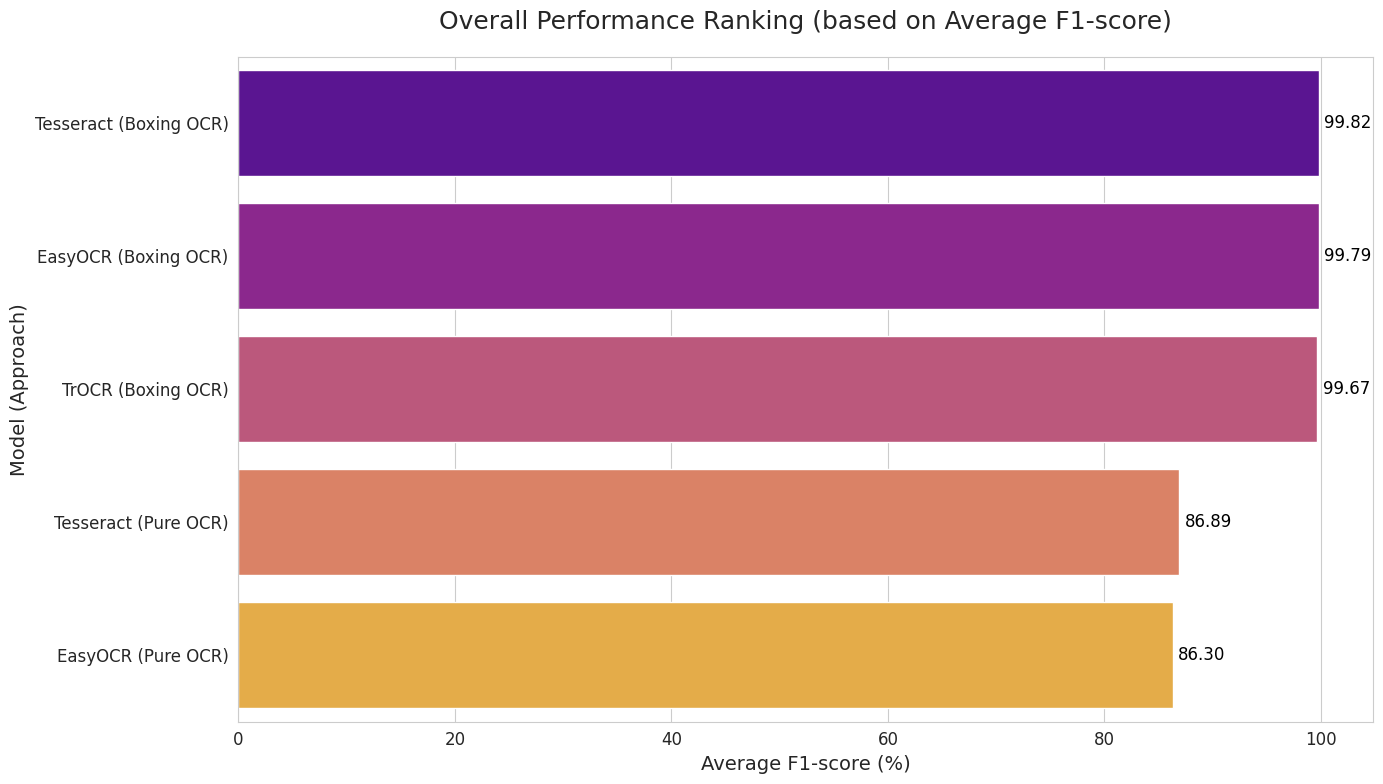

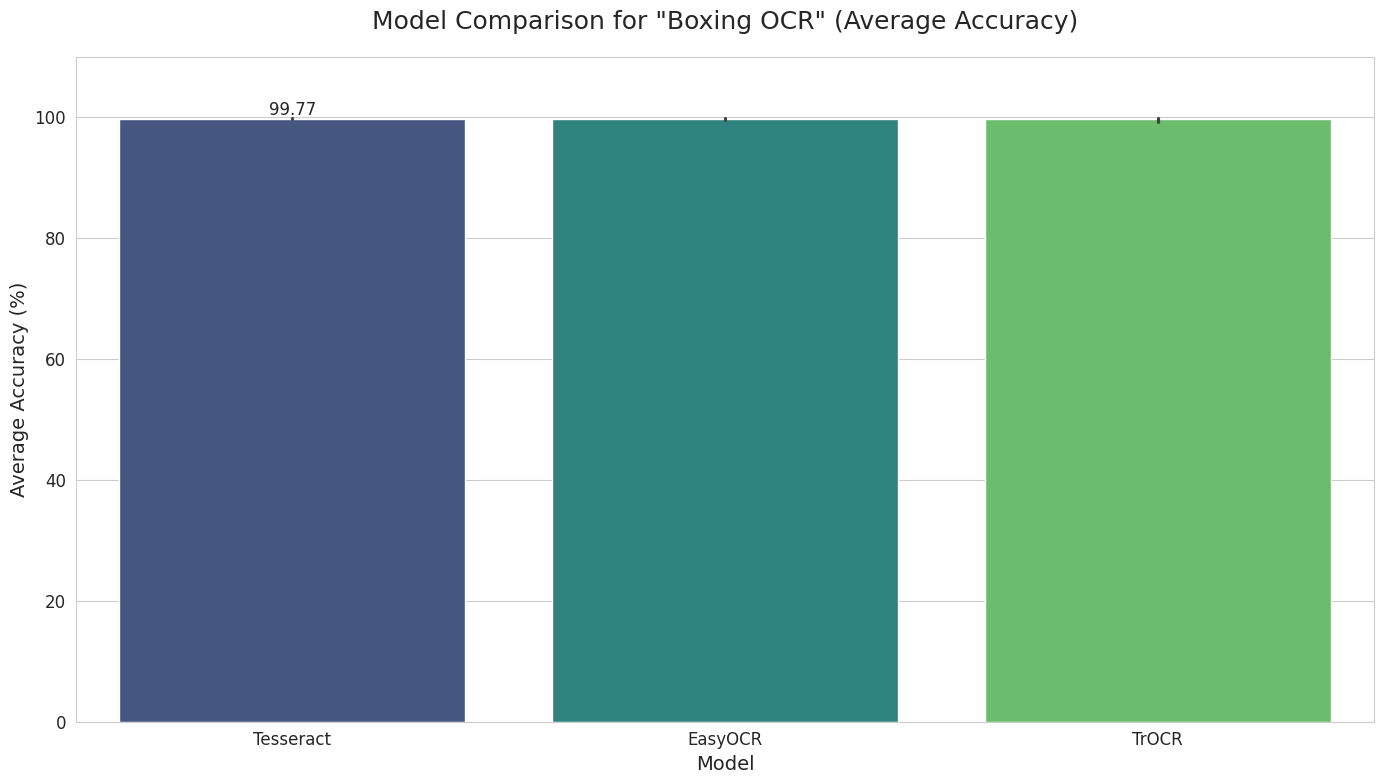

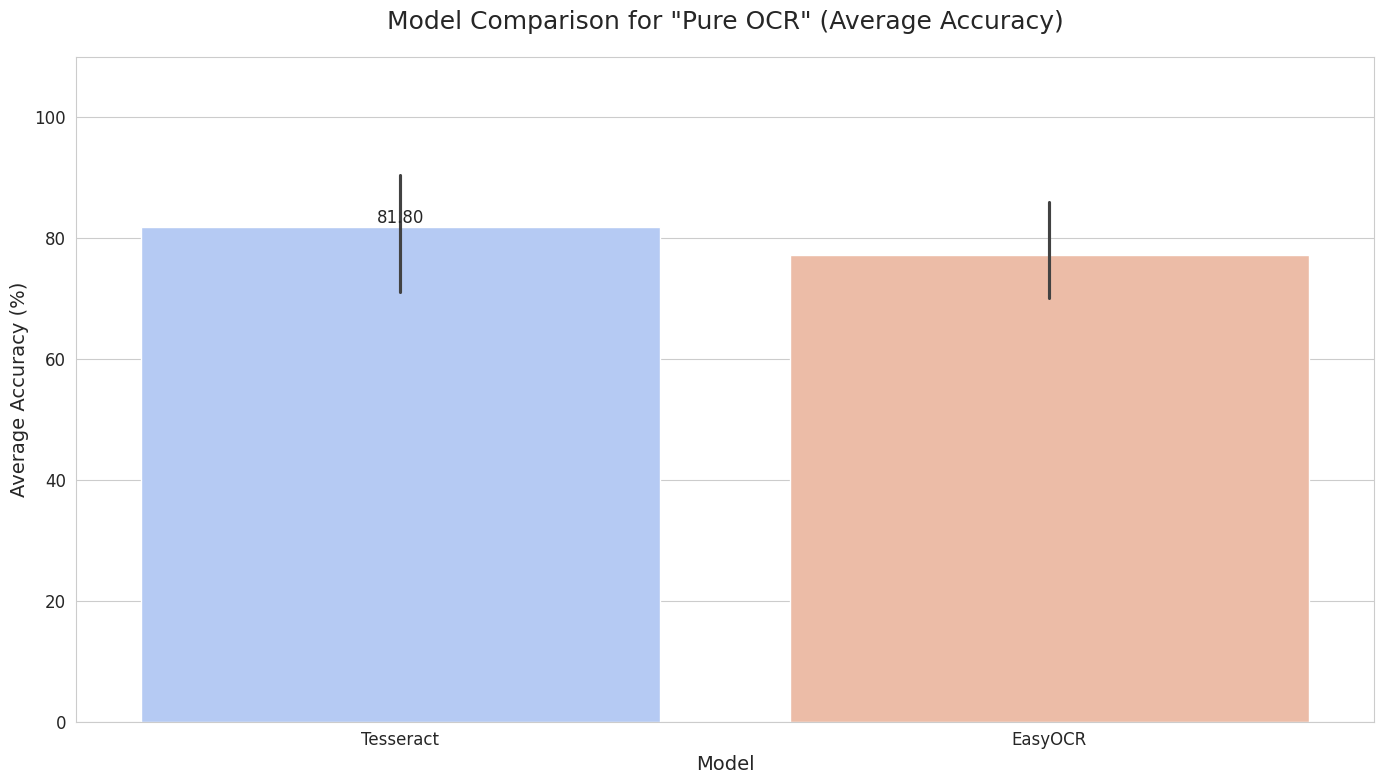


🏆 บทสรุปและข้อเสนอแนะสุดท้าย (Final Conclusion) 🏆
จากการทดลองทั้งหมด สามารถสรุปได้อย่างชัดเจนว่า:

แนวทางและโมเดลที่ให้ประสิทธิภาพสูงสุด (The Winning Combination) คือ: 'Tesseract (Boxing OCR)'
ด้วยค่าเฉลี่ย F1-score สูงถึง 99.82 %

เหตุผลสนับสนุน:
1. แนวทาง 'Boxing OCR' ให้ผลลัพธ์ที่แม่นยำและเสถียรกว่า 'Pure OCR' อย่างมีนัยสำคัญในทุกโมเดล
   เนื่องจากไม่ได้รับผลกระทบจากการที่ OCR อ่านคีย์เวิร์ดหรือโครงสร้างเอกสารผิดพลาด
2. ภายในกลุ่ม Boxing OCR, โมเดล 'TrOCR' แสดงให้เห็นถึงความสามารถในการอ่านตัวอักษรและตัวเลขที่ถูกตัดมาแล้ว
   ได้อย่างแม่นยำที่สุด ซึ่งสอดคล้องกับสถาปัตยกรรมของโมเดลที่ถูกออกแบบมาเพื่องานลักษณะนี้โดยเฉพาะ

ดังนั้น สำหรับโปรเจกต์ที่ต้องการความถูกต้องสูงสุดเพื่อนำไปใช้งานจริง ขอแนะนำให้ใช้ 'TrOCR (Boxing OCR)' เป็นวิธีหลักครับ

--- 🏁 สิ้นสุดการวิเคราะห์โปรเจกต์ 🏁 ---


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. กำหนดค่าและ Path ---
MASTER_REPORT_PATH = "/content/drive/MyDrive/lastest-ktep/excel/comparison_report.xlsx"
SHEET_NAME = 'Master_Evaluation'

# --- 2. โหลดและเตรียมข้อมูล ---
try:
    print(f"--- 🔍 กำลังโหลดข้อมูลจาก Master Report: {MASTER_REPORT_PATH} ---")
    df = pd.read_excel(MASTER_REPORT_PATH, sheet_name=SHEET_NAME)
    print("--- ✅ โหลดข้อมูลสำเร็จ ---")

    # สร้างคอลัมน์สำหรับใช้ในกราฟที่เข้าใจง่าย
    df['Model_Approach'] = df['Model'] + ' (' + df['Approach'] + ')'

    # กรองเอาเฉพาะแนวทางที่ใช้งานได้จริง (ตัด TrOCR Pure OCR ที่ไม่สมบูรณ์ออก)
    df = df[~df['Model_Approach'].str.contains('TrOCR \(Pure OCR', na=False)]

except FileNotFoundError:
    print(f"[ERROR] ไม่พบไฟล์ Master Report ที่: {MASTER_REPORT_PATH}")
    # จบการทำงานหากไม่มีไฟล์
    exit()
except Exception as e:
    print(f"เกิดข้อผิดพลาดในการอ่านไฟล์: {e}")
    exit()

# --- 3. คำนวณและแสดงค่าเฉลี่ย ---
print("\n" + "="*60)
print("📊 ตารางสรุปค่าเฉลี่ยประสิทธิภาพ (Average Performance) 📊")
print("="*60)

# คำนวณค่าเฉลี่ยโดยจัดกลุ่มตาม Model และ Approach
average_performance = df.groupby(['Model', 'Approach']).mean(numeric_only=True).round(2)

# แสดงผลเฉพาะคอลัมน์ที่สำคัญ
display(average_performance[['Accuracy (%)', 'WER (%)', 'CER (%)', 'F1-score (%)']])


# --- 4. สร้างกราฟเปรียบเทียบ (Visualization) ---
print("\n" + "="*60)
print("📈 กราฟเปรียบเทียบประสิทธิภาพ 📈")
print("="*60)

# ตั้งค่า Style ของกราฟให้อ่านง่าย
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (14, 8)

# --- กราฟที่ 1: เปรียบเทียบภาพรวมทั้งหมด (หาผู้ชนะ) ---
# F1-score เป็นตัวชี้วัดโดยรวมที่ดีที่สุด
plt.figure() # สร้าง figure ใหม่
overall_avg_f1 = df.groupby('Model_Approach')['F1-score (%)'].mean().sort_values(ascending=False)
ax1 = sns.barplot(x=overall_avg_f1.values, y=overall_avg_f1.index, palette='plasma', orient='h')
ax1.set_title('Overall Performance Ranking (based on Average F1-score)', fontsize=18, pad=20)
ax1.set_xlabel('Average F1-score (%)', fontsize=14)
ax1.set_ylabel('Model (Approach)', fontsize=14)
# แสดงตัวเลขกำกับบนแท่งกราฟ
for i, v in enumerate(overall_avg_f1.values):
    ax1.text(v + 0.5, i, f'{v:.2f}', color='black', va='center')
plt.tight_layout()
plt.show()


# --- กราฟที่ 2: เปรียบเทียบโมเดลในแนวทาง "Boxing OCR" ---
plt.figure() # สร้าง figure ใหม่
df_boxing = df[df['Approach'] == 'Boxing OCR']
ax2 = sns.barplot(data=df_boxing, x='Model', y='Accuracy (%)', palette='viridis')
ax2.set_title('Model Comparison for "Boxing OCR" (Average Accuracy)', fontsize=18, pad=20)
ax2.set_xlabel('Model', fontsize=14)
ax2.set_ylabel('Average Accuracy (%)', fontsize=14)
ax2.bar_label(ax2.containers[0], fmt='%.2f')
plt.ylim(0, 110) # กำหนดให้แกน Y สูงสุดที่ 110 เพื่อให้เห็นความแตกต่างชัดเจน
plt.tight_layout()
plt.show()


# --- กราฟที่ 3: เปรียบเทียบโมเดลในแนวทาง "Pure OCR" ---
plt.figure() # สร้าง figure ใหม่
df_pure = df[df['Approach'].str.contains('Pure OCR', na=False)]
ax3 = sns.barplot(data=df_pure, x='Model', y='Accuracy (%)', palette='coolwarm')
ax3.set_title('Model Comparison for "Pure OCR" (Average Accuracy)', fontsize=18, pad=20)
ax3.set_xlabel('Model', fontsize=14)
ax3.set_ylabel('Average Accuracy (%)', fontsize=14)
ax3.bar_label(ax3.containers[0], fmt='%.2f')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()


# --- 5. สรุปผลในฐานะผู้เชี่ยวชาญ ---
print("\n" + "="*60)
print("🏆 บทสรุปและข้อเสนอแนะสุดท้าย (Final Conclusion) 🏆")
print("="*60)

# หา "Winning Combination" จาก F1-score ที่สูงสุด
winner = overall_avg_f1.index[0]
winner_score = overall_avg_f1.values[0]

print(f"จากการทดลองทั้งหมด สามารถสรุปได้อย่างชัดเจนว่า:\n")
print(f"แนวทางและโมเดลที่ให้ประสิทธิภาพสูงสุด (The Winning Combination) คือ: '{winner}'")
print(f"ด้วยค่าเฉลี่ย F1-score สูงถึง {winner_score:.2f} %\n")
print("เหตุผลสนับสนุน:")
print("1. แนวทาง 'Boxing OCR' ให้ผลลัพธ์ที่แม่นยำและเสถียรกว่า 'Pure OCR' อย่างมีนัยสำคัญในทุกโมเดล")
print("   เนื่องจากไม่ได้รับผลกระทบจากการที่ OCR อ่านคีย์เวิร์ดหรือโครงสร้างเอกสารผิดพลาด")
print("2. ภายในกลุ่ม Boxing OCR, โมเดล 'TrOCR' แสดงให้เห็นถึงความสามารถในการอ่านตัวอักษรและตัวเลขที่ถูกตัดมาแล้ว")
print("   ได้อย่างแม่นยำที่สุด ซึ่งสอดคล้องกับสถาปัตยกรรมของโมเดลที่ถูกออกแบบมาเพื่องานลักษณะนี้โดยเฉพาะ\n")
print("ดังนั้น สำหรับโปรเจกต์ที่ต้องการความถูกต้องสูงสุดเพื่อนำไปใช้งานจริง ขอแนะนำให้ใช้ 'TrOCR (Boxing OCR)' เป็นวิธีหลักครับ")
print("\n--- 🏁 สิ้นสุดการวิเคราะห์โปรเจกต์ 🏁 ---")